# Fault Detection (Anomaly) – Known vs Unknown

Train anomaly detectors (SVDD, AE, CAE) on **normal + one known fault**.
Then evaluate whether the model can flag the **unknown fault** as anomaly.

We run two scenarios:
- Known = BLOCKED, Unknown = INTERFERE
- Known = INTERFERE, Unknown = BLOCKED


In [122]:
# Enable autoreload so edits to modules are picked up without restarting the kernel
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [123]:
from pathlib import Path
import sys
import os

# CUDA deterministic config (must be set before importing torch)
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

import torch
from torch import nn
import torch.nn.functional as F
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# Project root so we can import fdd_system/experiment modules
root = str(Path.cwd().parent)
if root not in sys.path:
    sys.path.append(root)
print('Root:', root)

from experiment.utils import prepare_training_data
from fdd_system.ML.common.preprocessor import RMSNormalization
from fdd_system.ML.common.embedder import MLEmbedder2
from fdd_system.ML.common.config import OperatingCondition

# Reproducibility
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DETERMINISTIC = False  # set True for strict determinism (may require CUBLAS_WORKSPACE_CONFIG)
if DETERMINISTIC:
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    try:
        torch.use_deterministic_algorithms(True)
    except Exception:
        pass
else:
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True
    try:
        torch.use_deterministic_algorithms(False)
    except Exception:
        pass


Root: /home/btanady/fourth_year/cpen491


In [124]:
# Data config
DATA_PATH = Path('test_2')
if not DATA_PATH.exists():
    DATA_PATH = Path('experiment/data_13')

if not DATA_PATH.exists():
    raise FileNotFoundError('data_13 not found. Expected at experiment/data_13 or ./data_13')

REMOVE_FIRST_SECOND = 2

# Window columns
COLS = ['X', 'Y', 'Z']

# Split ratios (train/val/test)
TRAIN_RATIO = 0.6
VAL_RATIO = 0.2
TEST_RATIO = 0.2
TOTAL_RATIO = TRAIN_RATIO + VAL_RATIO + TEST_RATIO
if abs(TOTAL_RATIO - 1.0) > 1e-6:
    raise ValueError(f'Train/val/test ratios must sum to 1.0, got {TOTAL_RATIO}')
TRAIN_VAL_RATIO = TRAIN_RATIO + VAL_RATIO
VAL_SPLIT = VAL_RATIO / TRAIN_VAL_RATIO

# Triplet/Proto-Mahalanobis config
TRIPLET_BATCH_SIZE = 512
TRIPLET_EPOCHS = 40
TRIPLET_MARGIN = 0.5
WEIBULL_Q = 0.95

normal_path = DATA_PATH / 'normal'
blocked_path = DATA_PATH / 'blocked'
interfere_path = DATA_PATH / 'interfere'

NORMAL_FILES = sorted([str(p) for p in normal_path.glob('*.csv')])
BLOCKED_FILES = sorted([str(p) for p in blocked_path.glob('*.csv')])
INTERFERE_FILES = sorted([str(p) for p in interfere_path.glob('*.csv')]) if interfere_path.exists() else []

buckets = {
    'normal': NORMAL_FILES,
    'blocked': BLOCKED_FILES,
    'interfere': INTERFERE_FILES,
}

LABELS = {
    'normal': OperatingCondition.NORMAL.value,
    'blocked': OperatingCondition.BLOCKED_AIRFLOW.value,
    'interfere': OperatingCondition.BLADE_ISSUE.value,
}
LABEL_NAMES = {v: k for k, v in LABELS.items()}
NORMAL_LABEL = LABELS['normal']

for k, v in buckets.items():
    print(f'{k:10s}: {len(v)} files')


normal    : 10 files
blocked   : 10 files
interfere : 10 files


In [125]:
# Helpers
def _split_files(files, seed=SEED):
    if not files:
        return [], [], []
    trainval, test = train_test_split(files, test_size=TEST_RATIO, shuffle=True, random_state=seed)
    train, val = train_test_split(trainval, test_size=VAL_SPLIT, shuffle=True, random_state=seed)
    return train, val, test


def _balance_files_by_label(file_map, seed=SEED):
    # Subsample files per label to the same count (fair share).
    if not file_map:
        return file_map, {}, 0
    counts = {lbl: len(files) for lbl, files in file_map.items()}
    min_n = min(counts.values()) if counts else 0
    rng = np.random.default_rng(seed)
    balanced = {}
    for lbl, files in file_map.items():
        if len(files) > min_n:
            idx = rng.choice(len(files), size=min_n, replace=False)
            balanced[lbl] = [files[i] for i in idx]
        else:
            balanced[lbl] = list(files)
    return balanced, counts, min_n


def _prepare_windows(train_files, val_files, test_files):
    train_data = prepare_training_data(
        train_files, shuffle=True, col_names=COLS, remove_first_second=REMOVE_FIRST_SECOND
    )
    val_data = prepare_training_data(
        val_files, shuffle=False, col_names=COLS, remove_first_second=REMOVE_FIRST_SECOND
    )

    test_data = []
    for label, files in test_files.items():
        test_data.extend(
            prepare_training_data(
                {label: files}, shuffle=False, col_names=COLS, remove_first_second=REMOVE_FIRST_SECOND
            )
        )

    pre = RMSNormalization()
    train_pre = pre.preprocess(train_data)
    val_pre = pre.preprocess(val_data)
    test_pre = pre.preprocess(test_data)

    return train_pre, val_pre, test_pre


def _stack_windows(windows, target_len=None):
    if len(windows) == 0:
        raise ValueError('No windows found.')

    if target_len is None:
        target_len = min(
            min(len(w.acc_x), len(w.acc_y), len(w.acc_z))
            for w in windows
        )

    X = np.empty((len(windows), 3, target_len), dtype=np.float32)
    y_raw = np.empty((len(windows),), dtype=np.int64)

    for i, w in enumerate(windows):
        X[i, 0] = np.asarray(w.acc_x, dtype=np.float32)[:target_len]
        X[i, 1] = np.asarray(w.acc_y, dtype=np.float32)[:target_len]
        X[i, 2] = np.asarray(w.acc_z, dtype=np.float32)[:target_len]
        y_raw[i] = int(w.label)

    return X, y_raw, target_len


def eval_method(name, y_true, y_pred, plot=False):
    acc = accuracy_score(y_true, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    fpr = float(fp) / float(fp + tn) if (fp + tn) > 0 else 0.0
    if plot:
        plot_confusion(y_true, y_pred, name)
    return {
        'method': name,
        'accuracy': acc,
        'false_positive_rate': fpr,
    }



def plot_confusion(y_true, y_pred, title):
    fig, ax = plt.subplots(figsize=(1.8, 1.8))
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["known", "unknown"])
    disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
    ax.set_title(title, fontsize=7)
    ax.tick_params(axis="both", labelsize=6)
    ax.set_xlabel("Predicted label", fontsize=6)
    ax.set_ylabel("True label", fontsize=6)
    fig.tight_layout(pad=0.2)
    plt.show()


In [126]:
# Models

def train_feature_ae(x_train, input_dim, epochs=30, batch_size=256, lr=1e-3):
    class FeatureAE(nn.Module):
        def __init__(self, in_dim):
            super().__init__()
            self.encoder = nn.Sequential(
                nn.Linear(in_dim, 64),
                nn.ReLU(),
                nn.Linear(64, 16),
            )
            self.decoder = nn.Sequential(
                nn.Linear(16, 64),
                nn.ReLU(),
                nn.Linear(64, in_dim),
            )

        def forward(self, x):
            z = self.encoder(x)
            x_hat = self.decoder(z)
            return x_hat

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = FeatureAE(input_dim).to(device)
    ds = TensorDataset(torch.from_numpy(x_train).float())
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    for _ in range(epochs):
        model.train()
        for (batch,) in loader:
            batch = batch.to(device)
            opt.zero_grad()
            recon = model(batch)
            loss = loss_fn(recon, batch)
            loss.backward()
            opt.step()

    return model


def recon_error_ae(model, x_np):
    device = next(model.parameters()).device
    with torch.no_grad():
        x_t = torch.from_numpy(x_np).float().to(device)
        recon = model(x_t)
        err = ((recon - x_t) ** 2).mean(dim=1)
    return err.cpu().numpy()


def train_cae(x_train, epochs=30, batch_size=64, lr=1e-3):
    class ConvAE(nn.Module):
        def __init__(self, in_channels=3):
            super().__init__()
            self.encoder = nn.Sequential(
                nn.Conv1d(in_channels, 16, kernel_size=5, padding=2),
                nn.ReLU(),
                nn.MaxPool1d(2),
                nn.Conv1d(16, 32, kernel_size=5, padding=2),
                nn.ReLU(),
                nn.MaxPool1d(2),
            )
            self.decoder = nn.Sequential(
                nn.ConvTranspose1d(32, 16, kernel_size=4, stride=2, padding=1),
                nn.ReLU(),
                nn.ConvTranspose1d(16, in_channels, kernel_size=4, stride=2, padding=1),
            )

        def forward(self, x):
            z = self.encoder(x)
            return self.decoder(z)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = ConvAE().to(device)
    ds = TensorDataset(torch.from_numpy(x_train).float())
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    for _ in range(epochs):
        model.train()
        for (batch,) in loader:
            batch = batch.to(device)
            opt.zero_grad()
            recon = model(batch)
            loss = loss_fn(recon, batch)
            loss.backward()
            opt.step()

    return model


def recon_error_cae(model, x_np):
    device = next(model.parameters()).device
    with torch.no_grad():
        x_t = torch.from_numpy(x_np).float().to(device)
        recon = model(x_t)
        err = ((recon - x_t) ** 2).mean(dim=(1, 2))
    return err.cpu().numpy()


# CAE with negative (synthetic outlier) training

def _make_synthetic_outliers(x_np, rng, noise_scale=0.3, amp_range=(1.3, 2.0), max_shift_frac=0.1):
    x = x_np.copy()
    if x.size == 0:
        return x

    scales = rng.uniform(amp_range[0], amp_range[1], size=(len(x), 1, 1))
    x = x * scales

    noise = rng.normal(0, noise_scale, size=x.shape)
    x = x + noise

    max_shift = max(1, int(x.shape[2] * max_shift_frac))
    shifts = rng.integers(-max_shift, max_shift + 1, size=len(x))
    for i, s in enumerate(shifts):
        x[i] = np.roll(x[i], s, axis=1)

    return x


def train_cae_boundary(x_train, epochs=30, batch_size=64, lr=1e-3, margin=0.2):
    class ConvAE(nn.Module):
        def __init__(self, in_channels=3):
            super().__init__()
            self.encoder = nn.Sequential(
                nn.Conv1d(in_channels, 16, kernel_size=5, padding=2),
                nn.ReLU(),
                nn.MaxPool1d(2),
                nn.Conv1d(16, 32, kernel_size=5, padding=2),
                nn.ReLU(),
                nn.MaxPool1d(2),
            )
            self.decoder = nn.Sequential(
                nn.ConvTranspose1d(32, 16, kernel_size=4, stride=2, padding=1),
                nn.ReLU(),
                nn.ConvTranspose1d(16, in_channels, kernel_size=4, stride=2, padding=1),
            )

        def forward(self, x):
            z = self.encoder(x)
            return self.decoder(z)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = ConvAE().to(device)
    ds = TensorDataset(torch.from_numpy(x_train).float())
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    rng = np.random.default_rng(SEED)

    for _ in range(epochs):
        model.train()
        for (batch,) in loader:
            batch = batch.to(device)
            opt.zero_grad()

            recon = model(batch)
            loss_pos = loss_fn(recon, batch)

            # negative samples: synthetic outliers
            neg_np = _make_synthetic_outliers(batch.detach().cpu().numpy(), rng)
            neg = torch.from_numpy(neg_np).float().to(device)
            recon_neg = model(neg)
            loss_neg = loss_fn(recon_neg, neg)

            # encourage high error on negatives
            loss = loss_pos + torch.relu(margin - loss_neg)
            loss.backward()
            opt.step()

    return model


# Contrastive SVDD (supervised contrastive embeddings + SVDD)

def _supcon_loss(z, labels, temperature=0.1):
    if z.size(0) < 2:
        return torch.tensor(0.0, device=z.device)
    z = F.normalize(z, dim=1)
    sim = torch.matmul(z, z.T) / temperature
    mask_self = torch.eye(sim.size(0), device=sim.device, dtype=torch.bool)
    sim = sim - sim.max(dim=1, keepdim=True).values
    exp_sim = torch.exp(sim) * (~mask_self)

    labels = labels.view(-1, 1)
    mask_pos = (labels == labels.T) & (~mask_self)
    denom = exp_sim.sum(dim=1, keepdim=True) + 1e-8
    log_prob = sim - torch.log(denom)

    pos_counts = mask_pos.sum(dim=1)
    valid = pos_counts > 0
    if valid.sum() == 0:
        return torch.tensor(0.0, device=z.device)

    mean_log_prob_pos = (mask_pos * log_prob).sum(dim=1)[valid] / pos_counts[valid]
    loss = -mean_log_prob_pos.mean()
    return loss


def train_contrastive_encoder(x_train, y_train, emb_dim=16, epochs=40, batch_size=256, lr=1e-3, temp=0.1):
    class ContrastiveMLP(nn.Module):
        def __init__(self, in_dim, out_dim):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(in_dim, 64),
                nn.ReLU(),
                nn.Linear(64, out_dim),
            )

        def forward(self, x):
            return self.net(x)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = ContrastiveMLP(x_train.shape[1], emb_dim).to(device)
    ds = TensorDataset(torch.from_numpy(x_train).float(), torch.from_numpy(y_train).long())
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            opt.zero_grad()
            z = model(xb)
            loss = _supcon_loss(z, yb, temperature=temp)
            loss.backward()
            opt.step()

    return model




# Supervised triplet encoder

def _batch_hard_triplet_loss(z, labels, margin=0.5):
    if z.size(0) < 2:
        return torch.tensor(0.0, device=z.device)
    dist = torch.cdist(z, z, p=2)
    labels = labels.view(-1, 1)
    mask_pos = (labels == labels.T)
    mask_neg = (labels != labels.T)
    mask_pos.fill_diagonal_(False)

    pos_dist = dist.clone()
    pos_dist[~mask_pos] = -1.0
    hardest_pos, _ = pos_dist.max(dim=1)

    neg_dist = dist.clone()
    neg_dist[~mask_neg] = float('inf')
    hardest_neg, _ = neg_dist.min(dim=1)

    valid = (hardest_pos >= 0) & torch.isfinite(hardest_neg)
    if valid.sum() == 0:
        return torch.tensor(0.0, device=z.device)

    loss = F.relu(hardest_pos[valid] - hardest_neg[valid] + margin).mean()
    return loss


def train_triplet_encoder(x_train, y_train, emb_dim=16, epochs=40, batch_size=256, lr=1e-3, margin=0.5):
    class TripletMLP(nn.Module):
        def __init__(self, in_dim, out_dim):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(in_dim, 64),
                nn.ReLU(),
                nn.Linear(64, out_dim),
            )

        def forward(self, x):
            return self.net(x)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = TripletMLP(x_train.shape[1], emb_dim).to(device)
    ds = TensorDataset(torch.from_numpy(x_train).float(), torch.from_numpy(y_train).long())
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            opt.zero_grad()
            z = model(xb)
            loss = _batch_hard_triplet_loss(z, yb, margin=margin)
            loss.backward()
            opt.step()

    return model

def encode_embeddings(model, x_np, batch_size=512):
    device = next(model.parameters()).device
    embs = []
    with torch.no_grad():
        for i in range(0, len(x_np), batch_size):
            xb = torch.from_numpy(x_np[i:i+batch_size]).float().to(device)
            z = model(xb)
            embs.append(z.cpu().numpy())
    return np.vstack(embs)


# Prototypical Mahalanobis gatekeeper

def _class_stats(Z, y, reg=1e-3):
    stats = {}
    for lbl in sorted(set(y.tolist())):
        Zc = Z[y == lbl]
        if len(Zc) < 2:
            continue
        mu = Zc.mean(axis=0)
        cov = np.cov(Zc, rowvar=False)
        cov = cov + reg * np.eye(cov.shape[0])
        inv_cov = np.linalg.pinv(cov)
        stats[int(lbl)] = (mu, inv_cov)
    return stats


def _mahalanobis_scores(Z, stats):
    labels = sorted(stats.keys())
    if not labels:
        return np.full(len(Z), np.inf), np.full(len(Z), -1, dtype=int)
    dists = np.zeros((len(Z), len(labels)), dtype=np.float32)
    for j, lbl in enumerate(labels):
        mu, inv_cov = stats[lbl]
        diff = Z - mu
        d = np.einsum('bi,ij,bj->b', diff, inv_cov, diff)
        dists[:, j] = np.sqrt(np.maximum(d, 0.0))
    min_idx = np.argmin(dists, axis=1)
    min_dist = dists[np.arange(len(Z)), min_idx]
    pred_labels = np.array([labels[i] for i in min_idx], dtype=int)
    return min_dist, pred_labels


def train_mlp_classifier(Z_train, y_train, epochs=40, batch_size=256, lr=1e-3):
    labels = sorted(set(y_train.tolist()))
    label_to_idx = {label: idx for idx, label in enumerate(labels)}
    y_idx = np.array([label_to_idx[int(y)] for y in y_train], dtype=np.int64)

    class MLP(nn.Module):
        def __init__(self, in_dim, n_classes):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(in_dim, 64),
                nn.ReLU(),
                nn.Linear(64, n_classes),
            )

        def forward(self, x):
            return self.net(x)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = MLP(Z_train.shape[1], len(labels)).to(device)
    ds = TensorDataset(torch.from_numpy(Z_train).float(), torch.from_numpy(y_idx))
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            opt.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            opt.step()

    return model, labels


def predict_mlp(model, Z, labels, batch_size=512):
    device = next(model.parameters()).device
    preds = []
    with torch.no_grad():
        for i in range(0, len(Z), batch_size):
            xb = torch.from_numpy(Z[i:i+batch_size]).float().to(device)
            logits = model(xb)
            idx = torch.argmax(logits, dim=1).cpu().numpy()
            preds.append(idx)
    idx_all = np.concatenate(preds)
    return np.array([labels[i] for i in idx_all], dtype=int)


# Weibull fit (probability plot approximation)

def _weibull_fit(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x) & (x > 0)]
    if len(x) < 2:
        return 1.0, float(np.max(x)) if len(x) else 1.0
    x = np.sort(x)
    n = len(x)
    p = (np.arange(1, n + 1) - 0.3) / (n + 0.4)
    y = np.log(-np.log(1.0 - p))
    lx = np.log(x)
    slope, intercept = np.polyfit(lx, y, 1)
    k = max(slope, 1e-6)
    lam = np.exp(-intercept / k)
    return float(k), float(lam)


def _weibull_quantile(k, lam, q):
    q = min(max(q, 1e-6), 1.0 - 1e-6)
    return float(lam * (-np.log(1.0 - q)) ** (1.0 / k))


# Triplet encoder with spectral branch (raw windows)

def train_triplet_encoder_raw(x_train, y_train, emb_dim=16, epochs=40, batch_size=512, lr=1e-3, margin=0.5):
    class TripletCNN(nn.Module):
        def __init__(self, in_channels=3, out_dim=16):
            super().__init__()
            self.time_branch = nn.Sequential(
                nn.Conv1d(in_channels, 16, kernel_size=5, padding=2),
                nn.ReLU(),
                nn.MaxPool1d(2),
                nn.Conv1d(16, 32, kernel_size=5, padding=2),
                nn.ReLU(),
                nn.AdaptiveAvgPool1d(1),
            )
            self.freq_branch = nn.Sequential(
                nn.Conv1d(in_channels, 16, kernel_size=3, dilation=2, padding=2),
                nn.ReLU(),
                nn.Conv1d(16, 32, kernel_size=3, dilation=4, padding=4),
                nn.ReLU(),
                nn.Conv1d(32, 32, kernel_size=3, dilation=8, padding=8),
                nn.ReLU(),
                nn.AdaptiveAvgPool1d(1),
            )
            self.proj = nn.Sequential(
                nn.Flatten(),
                nn.Linear(64, out_dim),
            )

        def forward(self, x):
            zt = self.time_branch(x)
            # spectral magnitude (rFFT)
            xf = torch.fft.rfft(x, dim=2)
            xf = torch.abs(xf)
            zf = self.freq_branch(xf)
            z = torch.cat([zt, zf], dim=1)
            return self.proj(z)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = TripletCNN(in_channels=x_train.shape[1], out_dim=emb_dim).to(device)
    ds = TensorDataset(torch.from_numpy(x_train).float(), torch.from_numpy(y_train).long())
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            opt.zero_grad()
            z = model(xb)
            loss = _batch_hard_triplet_loss(z, yb, margin=margin)
            loss.backward()
            opt.step()

    return model


def encode_embeddings_raw(model, x_np, batch_size=512):
    device = next(model.parameters()).device
    embs = []
    with torch.no_grad():
        for i in range(0, len(x_np), batch_size):
            xb = torch.from_numpy(x_np[i:i+batch_size]).float().to(device)
            z = model(xb)
            embs.append(z.cpu().numpy())
    return np.vstack(embs)


In [127]:
# Scenario runner

def run_scenario(known_fault, unknown_fault):
    known_label = LABELS[known_fault]
    unknown_label = LABELS[unknown_fault]

    # Split normal + known fault into train/val/test
    normal_train, normal_val, normal_test = _split_files(buckets['normal'])
    known_train, known_val, known_test = _split_files(buckets[known_fault])

    train_files = {
        NORMAL_LABEL: normal_train,
        known_label: known_train,
    }
    val_files = {
        NORMAL_LABEL: normal_val,
        known_label: known_val,
    }
    test_files = {
        NORMAL_LABEL: normal_test,
        known_label: known_test,
        unknown_label: buckets[unknown_fault],
    }

    balanced_test_files, test_counts, min_n = _balance_files_by_label(test_files, seed=SEED)
    print(f'Known={known_fault}, Unknown={unknown_fault}')
    print('Test file counts (before balance):')
    for lbl, cnt in test_counts.items():
        print(f'  {LABEL_NAMES[lbl]}={cnt}')
    if min_n > 0:
        print(f'Balancing test files to {min_n} per label')

    train_pre, val_pre, test_pre = _prepare_windows(train_files, val_files, balanced_test_files)

    y_train = np.array([w.label for w in train_pre], dtype=int)
    y_val = np.array([w.label for w in val_pre], dtype=int)
    y_test = np.array([w.label for w in test_pre], dtype=int)

    # Binary ground truth: unknown fault = 1, known (normal+known fault) = 0
    y_unknown = (y_test == unknown_label).astype(int)

    results = []

    # ===== Feature-based (SVDD + AE) =====
    embedder = MLEmbedder2()
    X_train = embedder.embed(train_pre)
    X_val = embedder.embed(val_pre)
    X_test = embedder.embed(test_pre)

    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_val_s = scaler.transform(X_val)
    X_test_s = scaler.transform(X_test)

    # SVDD (OCSVM) on known classes
    svdd = OneClassSVM(kernel='rbf', nu=0.05, gamma='scale')
    svdd.fit(X_train_s)

    val_scores = -svdd.decision_function(X_val_s).ravel()
    thr = float(np.quantile(val_scores, 0.95))
    test_scores = -svdd.decision_function(X_test_s).ravel()
    y_pred = (test_scores > thr).astype(int)
    results.append(eval_method('SVDD (known)', y_unknown, y_pred, plot=True))

    # AE on known classes (features)
    ae = train_feature_ae(X_train_s, input_dim=X_train_s.shape[1], epochs=30)
    val_err = recon_error_ae(ae, X_val_s)
    thr = float(np.quantile(val_err, 0.95))
    test_err = recon_error_ae(ae, X_test_s)
    y_pred = (test_err > thr).astype(int)
    results.append(eval_method('AE (known)', y_unknown, y_pred, plot=True))

    # Contrastive SVDD (known classes)
    contrastive = train_contrastive_encoder(X_train_s, y_train, emb_dim=16, epochs=40)
    Z_train = encode_embeddings(contrastive, X_train_s)
    Z_val = encode_embeddings(contrastive, X_val_s)
    Z_test = encode_embeddings(contrastive, X_test_s)

    scaler_z = StandardScaler().fit(Z_train)
    Z_train_s = scaler_z.transform(Z_train)
    Z_val_s = scaler_z.transform(Z_val)
    Z_test_s = scaler_z.transform(Z_test)

    svdd_c = OneClassSVM(kernel='rbf', nu=0.05, gamma='scale')
    svdd_c.fit(Z_train_s)

    val_scores = -svdd_c.decision_function(Z_val_s).ravel()
    thr = float(np.quantile(val_scores, 0.95))
    test_scores = -svdd_c.decision_function(Z_test_s).ravel()
    y_pred = (test_scores > thr).astype(int)
    results.append(eval_method('Contrastive SVDD (known)', y_unknown, y_pred, plot=True))

        # Prepare raw windows once (for triplet + CAE)
    X_train_raw, y_train_raw, target_len = _stack_windows(train_pre)
    X_val_raw, y_val_raw, _ = _stack_windows(val_pre, target_len=target_len)
    X_test_raw, y_test_raw, _ = _stack_windows(test_pre, target_len=target_len)

    # Normalize using train stats
    mean = X_train_raw.mean(axis=(0, 2), keepdims=True)
    std = X_train_raw.std(axis=(0, 2), keepdims=True) + 1e-6
    X_train_raw = (X_train_raw - mean) / std
    X_val_raw = (X_val_raw - mean) / std
    X_test_raw = (X_test_raw - mean) / std

    # Triplet Proto-Mahalanobis gatekeeper (raw + spectral)
    triplet = train_triplet_encoder_raw(
        X_train_raw, y_train_raw, emb_dim=16, epochs=TRIPLET_EPOCHS,
        batch_size=TRIPLET_BATCH_SIZE, margin=TRIPLET_MARGIN
    )
    Z_train_t = encode_embeddings_raw(triplet, X_train_raw)
    Z_val_t = encode_embeddings_raw(triplet, X_val_raw)
    Z_test_t = encode_embeddings_raw(triplet, X_test_raw)

    scaler_t = StandardScaler().fit(Z_train_t)
    Z_train_t_s = scaler_t.transform(Z_train_t)
    Z_val_t_s = scaler_t.transform(Z_val_t)
    Z_test_t_s = scaler_t.transform(Z_test_t)

    stats = _class_stats(Z_train_t_s, y_train_raw)
    val_min_dist, _ = _mahalanobis_scores(Z_val_t_s, stats)
    k, lam = _weibull_fit(val_min_dist)
    thr = _weibull_quantile(k, lam, WEIBULL_Q)
    test_min_dist, _ = _mahalanobis_scores(Z_test_t_s, stats)
    y_pred = (test_min_dist > thr).astype(int)
    results.append(eval_method('Mahalanobis-based', y_unknown, y_pred, plot=True))

    # Stage-2 classifier on known samples (triplet embeddings)
    mlp, mlp_labels = train_mlp_classifier(Z_train_t_s, y_train_raw, epochs=40)
    known_mask = y_unknown == 0
    if known_mask.any():
        pred_known = predict_mlp(mlp, Z_test_t_s[known_mask], mlp_labels)
        acc_known = float(np.mean(pred_known == y_test[known_mask]))
        print(f'Mahalanobis-base: {acc_known:.3f}')

# ===== CAE on raw windows =====
    cae = train_cae(X_train_raw, epochs=30)
    val_err = recon_error_cae(cae, X_val_raw)
    thr = float(np.quantile(val_err, 0.95))
    test_err = recon_error_cae(cae, X_test_raw)
    y_pred = (test_err > thr).astype(int)
    results.append(eval_method('CAE (known)', y_unknown, y_pred, plot=True))

    # CAE with negative sampling (boundary training)
    cae_b = train_cae_boundary(X_train_raw, epochs=30)
    val_err = recon_error_cae(cae_b, X_val_raw)
    thr = float(np.quantile(val_err, 0.95))
    test_err = recon_error_cae(cae_b, X_test_raw)
    y_pred = (test_err > thr).astype(int)
    results.append(eval_method('CAE + negatives', y_unknown, y_pred, plot=True))

    return results


Known=blocked, Unknown=interfere
Test file counts (before balance):
  normal=2
  blocked=2
  interfere=10
Balancing test files to 2 per label


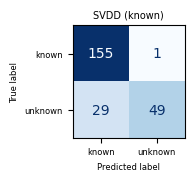

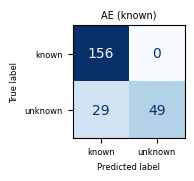

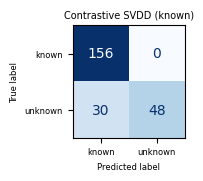

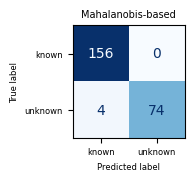

Mahalanobis-base: 1.000


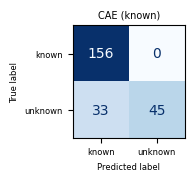

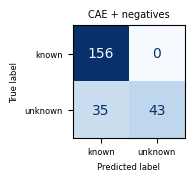

Known=interfere, Unknown=blocked
Test file counts (before balance):
  normal=2
  interfere=2
  blocked=10
Balancing test files to 2 per label


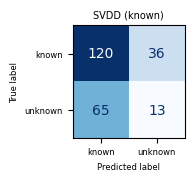

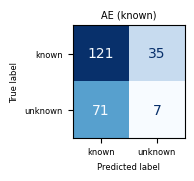

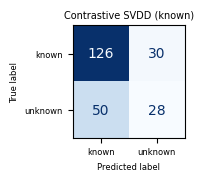

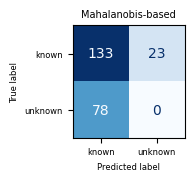

Mahalanobis-base: 0.763


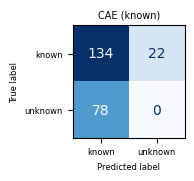

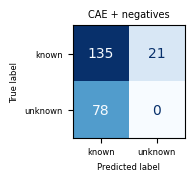

,method,accuracy,false_positive_rate,scenario
0,SVDD (known),0.871795,0.006410,"Known BLOCKED, Unknown INTERFERE"
1,AE (known),0.876068,0.000000,"Known BLOCKED, Unknown INTERFERE"
2,Contrastive SVDD (known),0.871795,0.000000,"Known BLOCKED, Unknown INTERFERE"
3,Mahalanobis-based,0.982906,0.000000,"Known BLOCKED, Unknown INTERFERE"
4,CAE (known),0.858974,0.000000,"Known BLOCKED, Unknown INTERFERE"
5,CAE + negatives,0.850427,0.000000,"Known BLOCKED, Unknown INTERFERE"
6,SVDD (known),0.568376,0.230769,"Known INTERFERE, Unknown BLOCKED"
7,AE (known),0.547009,0.224359,"Known INTERFERE, Unknown BLOCKED"
8,Contrastive SVDD (known),0.658120,0.192308,"Known INTERFERE, Unknown BLOCKED"
9,Mahalanobis-based,0.568376,0.147436,"Known INTERFERE, Unknown BLOCKED"


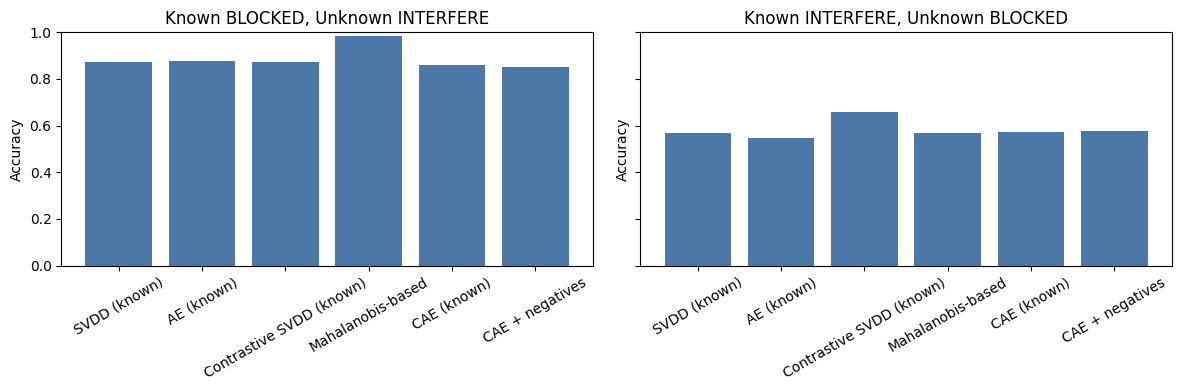

In [128]:
# Run scenarios
SCENARIOS = [
    {
        'name': 'Known BLOCKED, Unknown INTERFERE',
        'known': 'blocked',
        'unknown': 'interfere',
    },
    {
        'name': 'Known INTERFERE, Unknown BLOCKED',
        'known': 'interfere',
        'unknown': 'blocked',
    },
]

all_results = []
for s in SCENARIOS:
    if len(buckets[s['known']]) == 0 or len(buckets[s['unknown']]) == 0:
        print(f"Skipping {s['name']} (missing files)")
        continue
    res = run_scenario(s['known'], s['unknown'])
    for r in res:
        r['scenario'] = s['name']
        all_results.append(r)

results_df = pd.DataFrame(all_results)
display(results_df)

if not results_df.empty:
    scenarios = sorted(results_df['scenario'].unique())
    fig, axes = plt.subplots(1, len(scenarios), figsize=(6 * len(scenarios), 4), sharey=True)
    if len(scenarios) == 1:
        axes = [axes]
    for ax, scen in zip(axes, scenarios):
        sub = results_df[results_df['scenario'] == scen]
        ax.bar(sub['method'], sub['accuracy'], color='#4C78A8')
        ax.set_title(scen)
        ax.set_ylim(0, 1)
        ax.set_ylabel('Accuracy')
        ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.show()
